> Importando e exibindo os dados que serão analisados

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('full_data.csv')
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
4976,Male,41.0,0,0,No,Private,Rural,70.15,29.8,formerly smoked,0
4977,Male,40.0,0,0,Yes,Private,Urban,191.15,31.1,smokes,0
4978,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,31.8,smokes,0
4979,Male,40.0,0,0,Yes,Private,Rural,83.94,30.0,smokes,0


> Para melhor análise dos dados, vamos converter as classes que ainda não são numéricos, com o objetivo de facilitar a análise de dados que serão usados no classificador bayesiano.


>Transformando as variáveis referente ao genero em números, em que masculino == 0 e feminino ==1.

In [ ]:
df['gender'] = df['gender'].apply(lambda x: str(x).replace("Male","0"))
df['gender']

0            0
1            0
2       Female
3       Female
4            0
         ...  
4976         0
4977         0
4978    Female
4979         0
4980    Female
Name: gender, Length: 4981, dtype: object

In [ ]:
df['gender'] = df['gender'].apply(lambda x: str(x).replace("Female","1"))
df['gender']

0       0
1       0
2       1
3       1
4       0
       ..
4976    0
4977    0
4978    1
4979    0
4980    1
Name: gender, Length: 4981, dtype: object

In [ ]:
df['gender'] = df['gender'].astype('int64')
df['gender']

0       0
1       0
2       1
3       1
4       0
       ..
4976    0
4977    0
4978    1
4979    0
4980    1
Name: gender, Length: 4981, dtype: int64

> Exibindo os dados de 'gender' em gráfico, para entender melhor a distribuição das suas classificações.

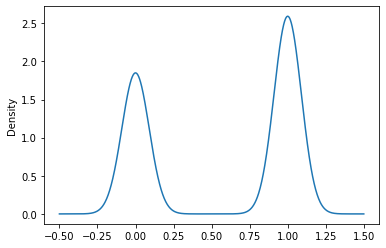

In [ ]:
df['gender'].plot(kind = 'kde')

> Gráfico de 'age', a qual já se encontra em caratér numérico e não foi necessário modificar.


obs = esse gráfico foi do tipo histograma para melhor compreender a variação de idade, visto que as opções são maiores.

In [ ]:
df['age'] = df['age'].astype('int64')
df['age']

0       67
1       80
2       49
3       79
4       81
        ..
4976    41
4977    40
4978    45
4979    40
4980    80
Name: age, Length: 4981, dtype: int64

> Divisão da categoria de idade:

> Criança;

> Jovem;

> Adulto;

> Idoso;

In [ ]:
def classificar_age(x): 
  if x <= 12:
    resp = 0
  elif x >= 13 and x <= 18:
    resp = 1
  elif x >= 19 and x <= 29:
    resp = 2
  elif x >= 30 and x <= 65:
    resp = 3
  else : 
    resp = 4
  
  return resp


In [ ]:
df['age'] = df['age'].apply(lambda x: classificar_age(x))

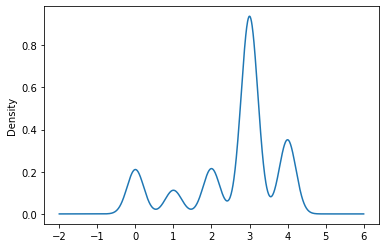

In [ ]:
df['age'].plot(kind = 'kde')

> Gráfico de 'hypertension', a qual já se encontra em caratér numérico e não foi necessário modificar.

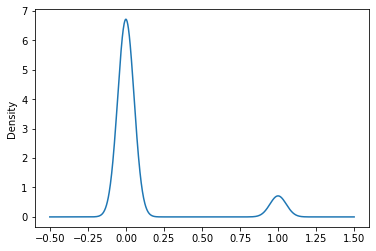

In [ ]:
df['hypertension'].plot(kind = 'kde')

> Gráfico de 'heart_disease', a qual já se encontra em caratér numérico e não foi necessário modificar.

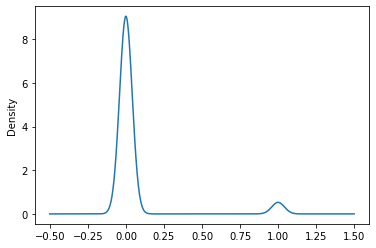

In [ ]:
df['heart_disease'].plot(kind = 'kde')

> Transformando as variáveis referente a situação conjugal (se é casado ou não) em números, em que Yes  == 0 e No ==1.

In [ ]:
df['ever_married'] = df['ever_married'].apply(lambda x: str(x).replace("Yes","1"))
df['ever_married']

0        1
1        1
2        1
3        1
4        1
        ..
4976    No
4977     1
4978     1
4979     1
4980     1
Name: ever_married, Length: 4981, dtype: object

In [ ]:
df['ever_married'] = df['ever_married'].apply(lambda x: str(x).replace("No","0"))
df['ever_married']

0       1
1       1
2       1
3       1
4       1
       ..
4976    0
4977    1
4978    1
4979    1
4980    1
Name: ever_married, Length: 4981, dtype: object

In [ ]:
df['ever_married'] = df['ever_married'].astype('int64')
df['ever_married']

0       1
1       1
2       1
3       1
4       1
       ..
4976    0
4977    1
4978    1
4979    1
4980    1
Name: ever_married, Length: 4981, dtype: int64

> Exibindo os dados de 'ever_married' em gráfico, para entender melhor a distribuição das suas classficicações.

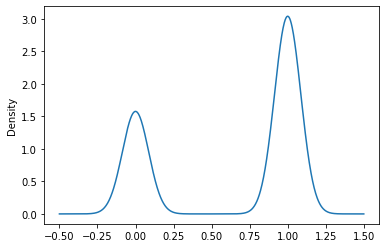

In [ ]:
df['ever_married'].plot(kind = 'kde')

> Transformando as variáveis referente a situação de trabalho em números, em que Privado == 0 , Trabalha para o Governo  ==1, Trabalha independente == 2, Crianças == 3.

In [ ]:
df['work_type'] = df['work_type'].apply(lambda x: str(x).replace("Private","0"))
df['work_type']

0                   0
1                   0
2                   0
3       Self-employed
4                   0
            ...      
4976                0
4977                0
4978         Govt_job
4979                0
4980                0
Name: work_type, Length: 4981, dtype: object

In [ ]:
df['work_type'] = df['work_type'].apply(lambda x: str(x).replace("Govt_job","1"))
df['work_type']

0                   0
1                   0
2                   0
3       Self-employed
4                   0
            ...      
4976                0
4977                0
4978                1
4979                0
4980                0
Name: work_type, Length: 4981, dtype: object

In [ ]:
df['work_type'] = df['work_type'].apply(lambda x: str(x).replace("Self-employed","2"))
df['work_type']

0       0
1       0
2       0
3       2
4       0
       ..
4976    0
4977    0
4978    1
4979    0
4980    0
Name: work_type, Length: 4981, dtype: object

In [ ]:
df['work_type'] = df['work_type'].apply(lambda x: str(x).replace("children","3"))
df['work_type']

0       0
1       0
2       0
3       2
4       0
       ..
4976    0
4977    0
4978    1
4979    0
4980    0
Name: work_type, Length: 4981, dtype: object

In [ ]:
df['work_type'] = df['work_type'].astype('int64')
df['work_type']

0       0
1       0
2       0
3       2
4       0
       ..
4976    0
4977    0
4978    1
4979    0
4980    0
Name: work_type, Length: 4981, dtype: int64

> Exibindo os dados de 'work_type' em gráfico, para entender melhor a distribuição das suas classficicações.

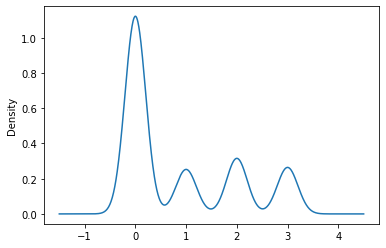

In [ ]:
df['work_type'].plot(kind = 'kde')

> Transformando o "residence_type" em dados numéricos, em que Urban == 0 e Rural == 1.




In [ ]:
df['Residence_type'] = df['Residence_type'].apply(lambda x: str(x).replace("Urban","0"))
df['Residence_type']

0           0
1       Rural
2           0
3       Rural
4           0
        ...  
4976    Rural
4977        0
4978    Rural
4979    Rural
4980        0
Name: Residence_type, Length: 4981, dtype: object

In [ ]:
df['Residence_type'] = df['Residence_type'].apply(lambda x: str(x).replace("Rural","1"))
df['Residence_type']

0       0
1       1
2       0
3       1
4       0
       ..
4976    1
4977    0
4978    1
4979    1
4980    0
Name: Residence_type, Length: 4981, dtype: object

In [ ]:
df['Residence_type'] = df['Residence_type'].astype('int64')
df['Residence_type']

0       0
1       1
2       0
3       1
4       0
       ..
4976    1
4977    0
4978    1
4979    1
4980    0
Name: Residence_type, Length: 4981, dtype: int64

> Exibindo os dados de 'Residence_type' em gráfico, para entender melhor a distribuição das suas classficicações.

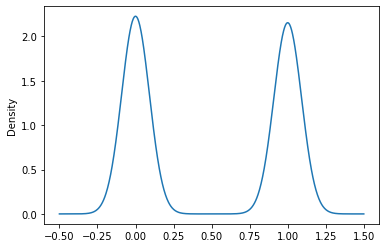

In [ ]:
df['Residence_type'].plot(kind = 'kde')

> Gráfico de 'avg_glucose_level', a qual já se encontra em caratér numérico e não foi necessário modificar.

obs = esse gráfico foi do tipo histograma para melhor compreender as variações, visto que as opções são maiores.

In [ ]:
df['avg_glucose_level'] = df['avg_glucose_level'].astype('int64')
df['avg_glucose_level']

0       228
1       105
2       171
3       174
4       186
       ... 
4976     70
4977    191
4978     95
4979     83
4980     83
Name: avg_glucose_level, Length: 4981, dtype: int64

> Níveis de glicose :

alta ( até 100) (0)

média ( até 126) (1)

alta ( maior que 126) (2) 

In [ ]:
def classificar_avg_glucose_level(x):
  resp = 0
  if x < 0 or x >= 100:
    resp = 0
  elif x >= 101 and x <= 126:
    resp = 1
  else: 
    resp = 2
 
  return resp

In [ ]:
df['avg_glucose_level'] = df['avg_glucose_level'].apply(lambda x: classificar_avg_glucose_level(x))

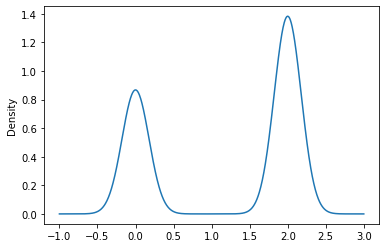

In [ ]:
df['avg_glucose_level'].plot(kind = 'kde')

> Gráfico de 'bmi', a qual já se encontra em caratér numérico e não foi necessário modificar.

obs = esse gráfico foi do tipo histograma para melhor compreender as variações, visto que as opções são maiores.

In [ ]:
df['bmi'] = df['bmi'].astype('int64')
df['bmi']

0       36
1       32
2       34
3       24
4       29
        ..
4976    29
4977    31
4978    31
4979    30
4980    29
Name: bmi, Length: 4981, dtype: int64

In [ ]:
def classificar_bmi(x):
  resp = 0
  if x <= 18:
    resp = 0
  elif x >= 19 and x <= 25:
    resp = 1
  else: 
    resp = 2
 
  return resp

In [ ]:
df['bmi'] = df['bmi'].apply(lambda x: classificar_bmi(x))

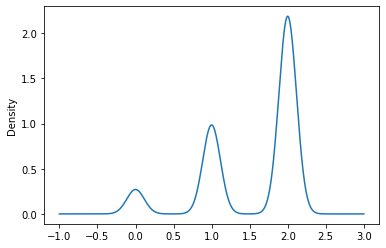

In [ ]:
df['bmi'].plot(kind = 'kde')

> Transformando o "smoking_status" em dados numéricos, em que smoked == 0 , never smoked == 1 , smokes == 2 e  Unknown == 3.

In [ ]:
df['smoking_status'] = df['smoking_status'].apply(lambda x: str(x).replace("formerly smoked","0"))
df['smoking_status']

0                  0
1       never smoked
2             smokes
3       never smoked
4                  0
            ...     
4976               0
4977          smokes
4978          smokes
4979          smokes
4980    never smoked
Name: smoking_status, Length: 4981, dtype: object

In [ ]:
df['smoking_status'] = df['smoking_status'].apply(lambda x: str(x).replace("never smoked","1"))
df['smoking_status']

0            0
1            1
2       smokes
3            1
4            0
         ...  
4976         0
4977    smokes
4978    smokes
4979    smokes
4980         1
Name: smoking_status, Length: 4981, dtype: object

In [ ]:
df['smoking_status'] = df['smoking_status'].apply(lambda x: str(x).replace("smokes","2"))
df['smoking_status']

0       0
1       1
2       2
3       1
4       0
       ..
4976    0
4977    2
4978    2
4979    2
4980    1
Name: smoking_status, Length: 4981, dtype: object

In [ ]:
df['smoking_status'] = df['smoking_status'].apply(lambda x: str(x).replace("Unknown","3"))
df['smoking_status']

0       0
1       1
2       2
3       1
4       0
       ..
4976    0
4977    2
4978    2
4979    2
4980    1
Name: smoking_status, Length: 4981, dtype: object

In [ ]:
df['smoking_status'] = df['smoking_status'].astype('int64')
df['smoking_status']

0       0
1       1
2       2
3       1
4       0
       ..
4976    0
4977    2
4978    2
4979    2
4980    1
Name: smoking_status, Length: 4981, dtype: int64

> Exibindo os dados de 'smoking_status' em gráfico, para entender melhor a distribuição das suas classficicações.

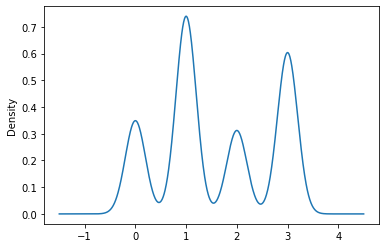

In [ ]:
df['smoking_status'].plot(kind = 'kde')

> Gráfico de 'stroke', a qual já se encontra em caratér numérico e não foi necessário modificar.

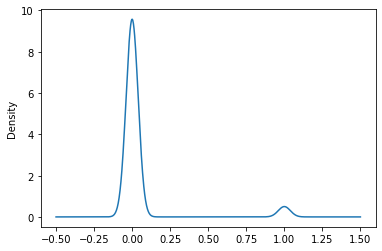

In [ ]:
df['stroke'].plot(kind = 'kde')

> Tabela geral da análise das classes dos dados, em que podemos vizualizar alguns dados estatísiticos válidos, como a média e o desvio padrão.
>> Observação geral : as variações 0 e 1  já determinadas no df, eu não consegui concluir qual é o verdadeiro e qual é o falso com exatidão (exemplo hypertension).

In [ ]:
df[['gender',	'age'	, 'hypertension', 	'heart_disease',  'ever_married',	'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']].describe()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000
mean,0.583618,2.606304,0.096165,0.055210,0.658502,0.857458,0.491668,1.229070,1.556916,1.584019,0.049789
std,0.493008,1.199311,0.294848,0.228412,0.474260,1.120706,0.499981,0.973508,0.635483,1.092516,0.217531
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
50%,1.000000,3.000000,0.000000,0.000000,1.000000,0.000000,0.000000,2.000000,2.000000,1.000000,0.000000
75%,1.000000,3.000000,0.000000,0.000000,1.000000,2.000000,1.000000,2.000000,2.000000,3.000000,0.000000
max,1.000000,4.000000,1.000000,1.000000,1.000000,3.000000,1.000000,2.000000,2.000000,3.000000,1.000000


> Coluna das classes que analisamos nesse dado.

In [ ]:
columns = df.columns
for column in columns:
  print(column)

gender
age
hypertension
heart_disease
ever_married
work_type
Residence_type
avg_glucose_level
bmi
smoking_status
stroke


> Matriz de relaçao de dependência.

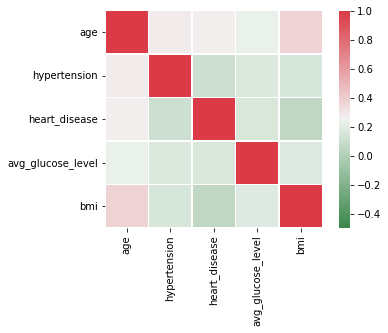

In [ ]:
corr = df.iloc[:,:-1].corr(method="pearson")
cmap = sns.diverging_palette(133, 10, as_cmap=True)
sns.heatmap(corr, vmax=1, vmin=-.5, cmap=cmap, square=True, linewidths=.2)

> A partir dessa matriz, vemos que o bmi possui uma relação de dependência com o age, portanto não vamos urilizar essa classe no nosso classificador.

In [ ]:
df.drop(inplace = True, columns = "bmi")

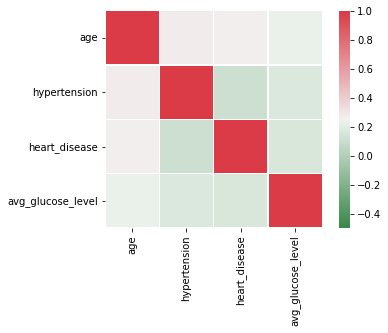

In [ ]:
corr = df.iloc[:,:-1].corr(method="pearson")
cmap = sns.diverging_palette(133, 10, as_cmap=True)
sns.heatmap(corr, vmax=1, vmin=-.5, cmap=cmap, square=True, linewidths=.2)